In [1]:
from google.colab import files
import zipfile, os

uploaded = files.upload()
zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('resume_data')

for f in os.listdir('resume_data'):
    print(f)

Saving archive (6).zip to archive (6).zip
data
Resume


In [3]:
import pandas as pd
import os

# Check what's inside the extracted folders
for root, dirs, files in os.walk('resume_data'):
    for file in files:
        print(os.path.join(root, file))

resume_data/data/data/FINANCE/86595128.pdf
resume_data/data/data/FINANCE/14408510.pdf
resume_data/data/data/FINANCE/38441665.pdf
resume_data/data/data/FINANCE/28973180.pdf
resume_data/data/data/FINANCE/28724469.pdf
resume_data/data/data/FINANCE/27018361.pdf
resume_data/data/data/FINANCE/26767199.pdf
resume_data/data/data/FINANCE/18975686.pdf
resume_data/data/data/FINANCE/21912637.pdf
resume_data/data/data/FINANCE/59450123.pdf
resume_data/data/data/FINANCE/38907798.pdf
resume_data/data/data/FINANCE/91564103.pdf
resume_data/data/data/FINANCE/19147603.pdf
resume_data/data/data/FINANCE/24967652.pdf
resume_data/data/data/FINANCE/25497147.pdf
resume_data/data/data/FINANCE/37931076.pdf
resume_data/data/data/FINANCE/22720697.pdf
resume_data/data/data/FINANCE/15891494.pdf
resume_data/data/data/FINANCE/14413148.pdf
resume_data/data/data/FINANCE/18072085.pdf
resume_data/data/data/FINANCE/14722634.pdf
resume_data/data/data/FINANCE/29612672.pdf
resume_data/data/data/FINANCE/39295103.pdf
resume_data

In [5]:
import re
import pandas as pd

def clean_text(text):
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower().strip()
    return text

# Load the Resume.csv file into a DataFrame
df = pd.read_csv('resume_data/Resume/Resume.csv')

# Assuming there is a 'Resume_str' column in your CSV file
df['Cleaned_Resume'] = df['Resume_str'].apply(clean_text)
print(df['Cleaned_Resume'][0][:300])

hr administratormarketing associate

hr administrator       summary     dedicated customer service manager with  years of experience in hospitality and customer service management   respected builder and leader of customerfocused teams strives to instill a shared enthusiastic commitment to customer 


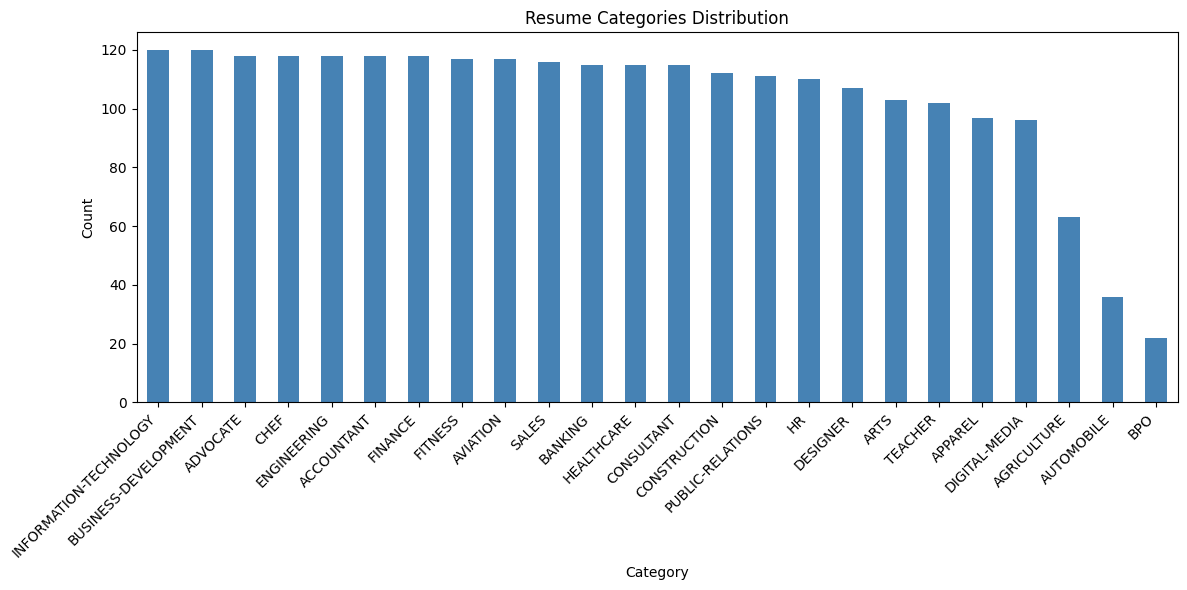

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
df['Category'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Resume Categories Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('category_distribution.png')
plt.show()

In [9]:
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Category_Encoded'] = le.fit_transform(df['Category'])

X_train, X_test, y_train, y_test = train_test_split(
    df['Cleaned_Resume'], df['Category_Encoded'], test_size=0.2, random_state=42)

tfidf = TfidfVectorizer(max_features=3000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

model = LinearSVC()
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.6901408450704225
                        precision    recall  f1-score   support

            ACCOUNTANT       0.81      0.90      0.85        29
              ADVOCATE       0.65      0.73      0.69        30
           AGRICULTURE       0.17      0.12      0.14         8
               APPAREL       0.60      0.60      0.60        20
                  ARTS       0.44      0.22      0.30        18
            AUTOMOBILE       0.50      0.17      0.25         6
              AVIATION       0.78      0.86      0.82        21
               BANKING       0.77      0.74      0.76        23
                   BPO       0.50      0.50      0.50         2
  BUSINESS-DEVELOPMENT       0.81      0.48      0.60        27
                  CHEF       0.86      0.75      0.80        24
          CONSTRUCTION       0.85      0.82      0.84        34
            CONSULTANT       0.47      0.35      0.40        20
              DESIGNER       0.77      0.89      0.83        19
         D

In [10]:
sample_resume = "Experienced Python developer with skills in machine learning, TensorFlow, and data analysis."

cleaned = clean_text(sample_resume)
vectorized = tfidf.transform([cleaned])
prediction = model.predict(vectorized)
print("Predicted Category:", le.inverse_transform(prediction)[0])

Predicted Category: AUTOMOBILE
